- Pipeline Flexivel, justificar o porque não usou o 'basico'

    - Normalização 0,255 - float

    - Filtros básicos da m1

    - ? Gerar superpixels 

    - Segmentação

    - Morfologia

    - Metricas ( libs )



Artigos de como é a implementação dos segmentadores


-


In [82]:
%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
from matplotlib import pyplot as plt
import functions_m2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Setup do Dataset
Dataset selecionado: Segmentação de Grãos Agrícolas [Link - Kaggle](https://www.kaggle.com/datasets/ddsssss/seed-images)


#### Enunciado
> Separar automaticamente grãos individuais em imagens adquiridas sobre fundo uniforme.
>
> ▪ Deve gerar uma máscara binária em que pixels pertencentes aos grãos sejam representados por valor 1 e pixels do fundo sejam representados por valor 0
>
> ▪ Desafios: grãos tocando uns aos outros, variação de tamanho e orientação, reflexos,
> ruído de fundo


#### Gabarito
 Nos arquivos do Dataset, é disponibilizado um 'Gabarito' em XML com as coordernadas de cada grão. 
 



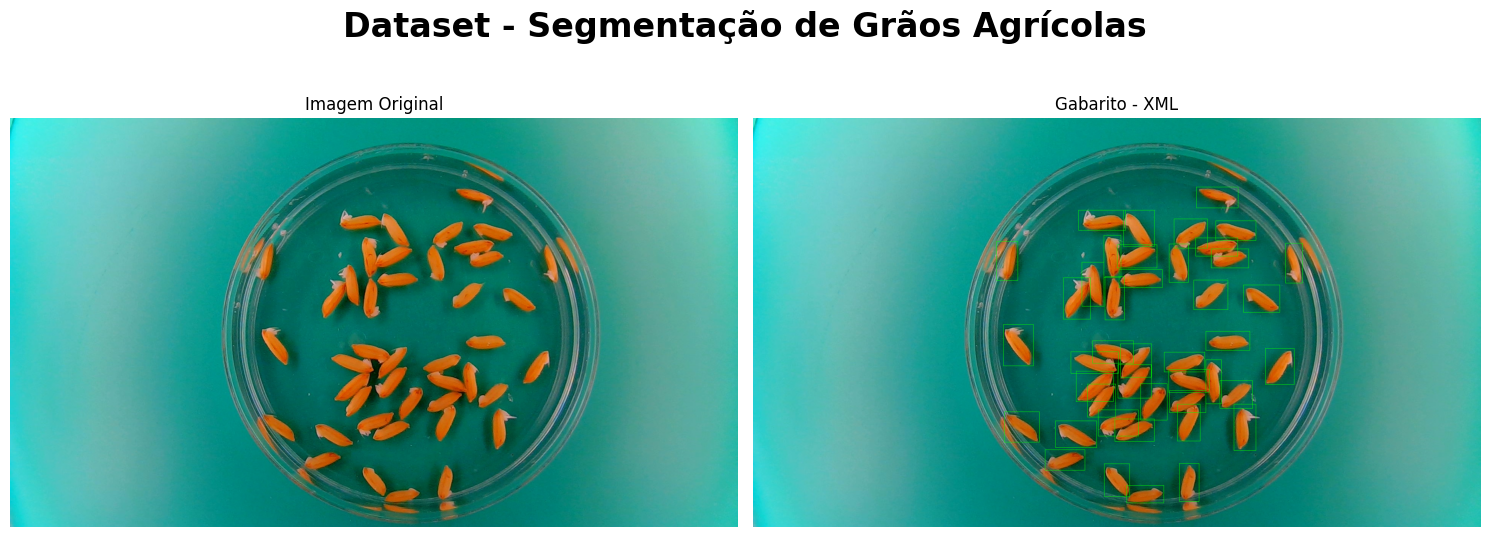

In [83]:
### DATASET
image_og_path = "data/0001.jpg"
### to RGB
image_og =  cv2.cvtColor(cv2.imread(image_og_path), cv2.COLOR_BGR2RGB)
### XML fornecido pelo dataset, destacando os grãos da imagem
gabarito_path = "data/0001.xml"

## Gabarito
gab_img =  functions_m2.gabarito(image_og_path, gabarito_path)

## Plot da imagens
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Dataset - Segmentação de Grãos Agrícolas" , fontsize=24, fontweight='bold')

axes[0].imshow(image_og)
axes[0].set_title(f'Imagem Original')
axes[0].axis('off')

axes[1].imshow(gab_img)
axes[1].set_title(f'Gabarito - XML')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Pré - Processamento

1. Escala de Cinza
2. Normalização - Float e clip 0, 255
> Utilizado a função .normalize() do OpenCV, limitando para 0,255 e o tipo para Float 32


Verificar se é viavel aplicar a normalização do historiograma.

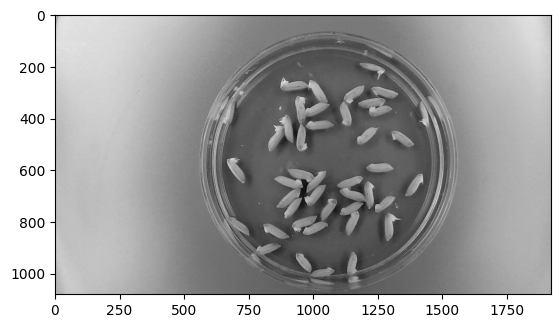

[[179 178 179 ... 151 150 148]
 [180 179 179 ... 151 150 148]
 [181 179 178 ... 152 150 148]
 ...
 [156 157 158 ... 139 140 140]
 [154 155 157 ... 141 141 142]
 [152 154 156 ... 142 143 143]]


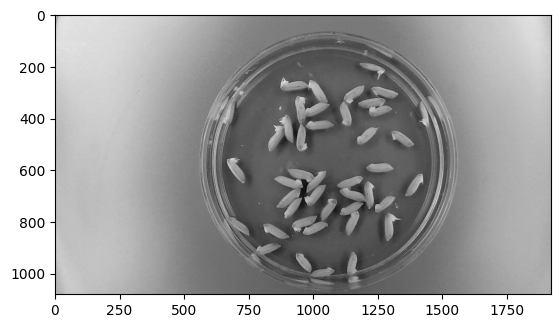

[[217.17702 215.95692 217.17702 ... 183.01434 181.79425 179.35406]
 [218.39713 217.17702 217.17702 ... 183.01434 181.79425 179.35406]
 [219.61722 217.17702 215.95692 ... 184.23444 181.79425 179.35406]
 ...
 [189.11482 190.33492 191.55501 ... 168.3732  169.59329 169.59329]
 [186.67464 187.89473 190.33492 ... 170.81339 170.81339 172.03348]
 [184.23444 186.67464 189.11482 ... 172.03348 173.25359 173.25359]]


In [84]:
gray_img = cv2.cvtColor(image_og, cv2.COLOR_RGB2GRAY)

plt.imshow(gray_img, cmap='gray')

plt.show()
print(gray_img)
norm_img = cv2.normalize(gray_img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
#cv2.CV_8U
plt.imshow(norm_img, cmap='gray')
plt.show()
print(norm_img)

## Filtragem no Dominio da Frequência


Parametro das funções de criações dos filtros: Passa Baixa e Passa Alta

Tipo de filtros: 0 = Ideal, 1 = ButterWorth, 2 = Gaussian
> Alterar depois p mostrar certinho no plot
 

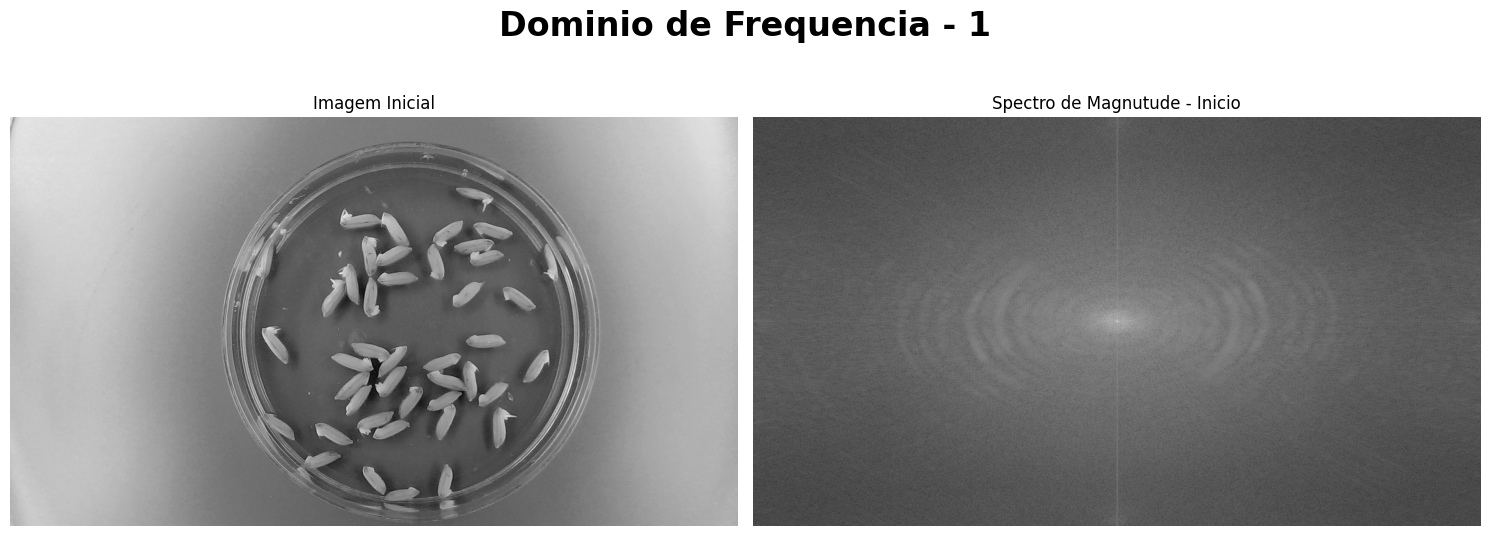

In [97]:

## Primeira fase Forier 2d com DFT
dft = cv2.dft(norm_img, flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

### Spectro de Magnuted, n entendi essa porra mas funciona
magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1])) 
magnitude_spectrum = np.abs(magnitude_spectrum)
magnitude_spectrum -= magnitude_spectrum.min()
magnitude_spectrum = magnitude_spectrum*255 / magnitude_spectrum.max()
magnitude_spectrum = magnitude_spectrum.astype(np.uint8)


## 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Dominio de Frequencia - 1" , fontsize=24, fontweight='bold')

axes[0].imshow(norm_img, cmap='gray')
axes[0].set_title(f'Imagem Inicial')
axes[0].axis('off')

axes[1].imshow(magnitude_spectrum, cmap = 'gray')
axes[1].set_title(f'Spectro de Magnutude - Inicio')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [86]:
### Segunda fase, aplicação do Filtros
# 
# 
# Variaveis das imagens p os filtros
nrows, ncols = dft_shift.shape[:2] 
real = np.power(dft_shift[:, :, 0], 2.0)
imaginary = np.power(dft_shift[:, :, 1], 2.0)
amplitude = np.sqrt(real+imaginary)
minValue, maxValue, minLoc, maxLoc = cv2.minMaxLoc(amplitude)

In [87]:

## PASSA BAIXA

maskPB = functions_m2.createPB(dft_shift.shape, center=maxLoc, radius=35, lpType=1, n=2)

filtered_freq = dft_shift*maskPB
f_ishift = np.fft.ifftshift(filtered_freq)  #inversa da fft
img_back = cv2.idft(f_ishift)        #inversa da dft
img_back = cv2.magnitude(img_back[:,:,0],img_back[:,:,1])  #recuperando a imagem capturando a magnitude (intesidade) 


img_back = np.array(img_back, dtype=np.float32)

print(img_back)
## Aplicação do Filtro e 
filtered_img = np.abs(img_back)
filtered_img -= filtered_img.min()
filtered_img = filtered_img*255 / filtered_img.max()
filtered_img = filtered_img.astype(np.uint8)

[[3.8611802e+08 3.8672573e+08 3.8733661e+08 ... 3.8446755e+08
  3.8497197e+08 3.8552746e+08]
 [3.8852141e+08 3.8912778e+08 3.8973754e+08 ... 3.8688291e+08
  3.8738083e+08 3.8793264e+08]
 [3.9075981e+08 3.9135885e+08 3.9196253e+08 ... 3.8915296e+08
  3.8963837e+08 3.9017974e+08]
 ...
 [3.7873334e+08 3.7932784e+08 3.7992477e+08 ... 3.7709466e+08
  3.7760285e+08 3.7815347e+08]
 [3.8113568e+08 3.8173478e+08 3.8233757e+08 ... 3.7949286e+08
  3.8000035e+08 3.8055264e+08]
 [3.8362378e+08 3.8422774e+08 3.8483558e+08 ... 3.8197590e+08
  3.8248253e+08 3.8303680e+08]]


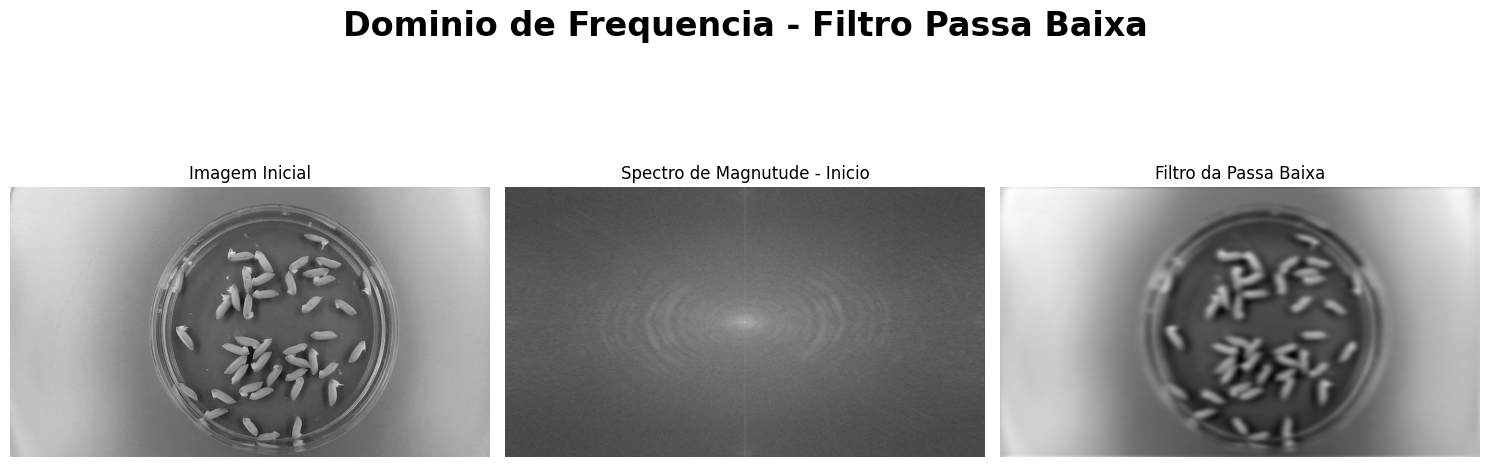

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle(f"Dominio de Frequencia - Filtro Passa Baixa" , fontsize=24, fontweight='bold')

axes[0].imshow(norm_img, cmap='gray')
axes[0].set_title(f'Imagem Inicial')
axes[0].axis('off')

axes[1].imshow(magnitude_spectrum, cmap = 'gray')
axes[1].set_title(f'Spectro de Magnutude - Inicio')
axes[1].axis('off')

axes[2].imshow(filtered_img, cmap = 'gray')
axes[2].set_title(f'Filtro da Passa Baixa')
axes[2].axis('off')
plt.tight_layout()
plt.show()

In [89]:
maskPA = functions_m2.createPA(dft_shift.shape, center=maxLoc, radius=35, lpType=0, n=1)

filtered_freq = dft_shift*maskPA
f_ishift = np.fft.ifftshift(filtered_freq)  #inversa da fft
img_back = cv2.idft(f_ishift)        #inversa da dft
img_back = cv2.magnitude(img_back[:,:,0],img_back[:,:,1])  #recuperando a imagem capturando a magnitude (intesidade) 


img_back = np.array(img_back, dtype=np.float32)

filtered_img = np.abs(img_back)
filtered_img -= filtered_img.min()
filtered_img = filtered_img*255 / filtered_img.max()
filtered_img = filtered_img.astype(np.uint8)

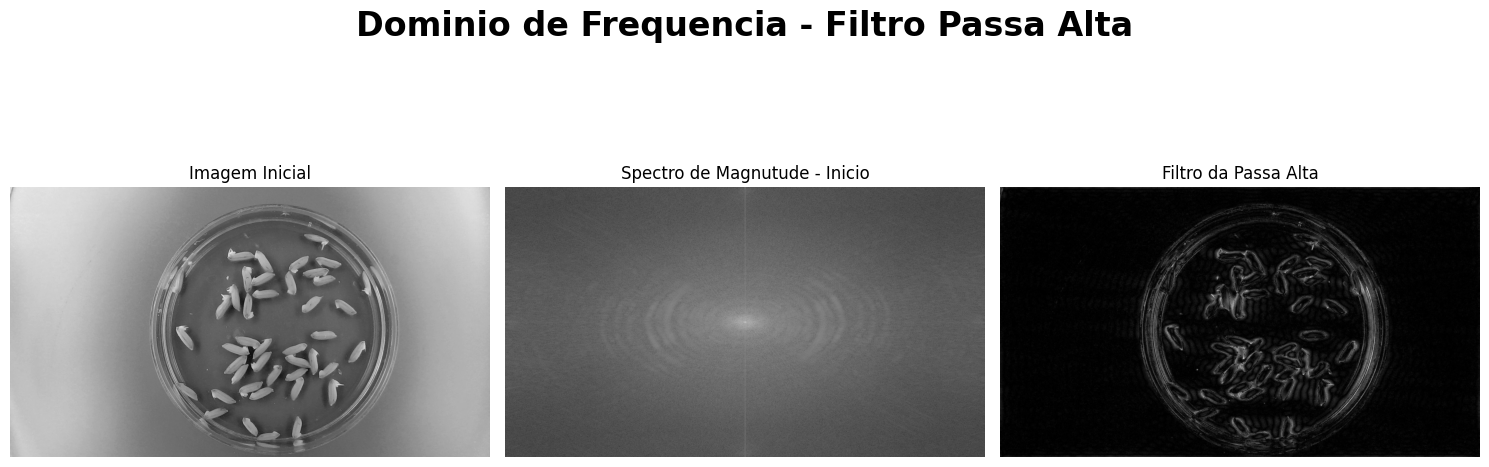

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle(f"Dominio de Frequencia - Filtro Passa Alta" , fontsize=24, fontweight='bold')

axes[0].imshow(norm_img, cmap='gray')
axes[0].set_title(f'Imagem Inicial')
axes[0].axis('off')

axes[1].imshow(magnitude_spectrum, cmap = 'gray')
axes[1].set_title(f'Spectro de Magnutude - Inicio')
axes[1].axis('off')

axes[2].imshow(filtered_img, cmap = 'gray')
axes[2].set_title(f'Filtro da Passa Alta')
axes[2].axis('off')
plt.tight_layout()
plt.show()

In [91]:
maskPF = functions_m2.createPF(shape=dft_shift.shape, center=maxLoc, bandCenter=1, bandWidth=400, lpType=2, n=2)

filtered_freq = dft_shift*maskPF
f_ishift = np.fft.ifftshift(filtered_freq)  #inversa da fft
img_back = cv2.idft(f_ishift)        #inversa da dft
img_back = cv2.magnitude(img_back[:,:,0],img_back[:,:,1])  #recuperando a imagem capturando a magnitude (intesidade) 


img_back = np.array(img_back, dtype=np.float32)

filtered_img = np.abs(img_back)
filtered_img -= filtered_img.min()
filtered_img = filtered_img*255 / filtered_img.max()
filtered_img = filtered_img.astype(np.uint8)

<string>:16: RuntimeWarning: divide by zero encountered in divide


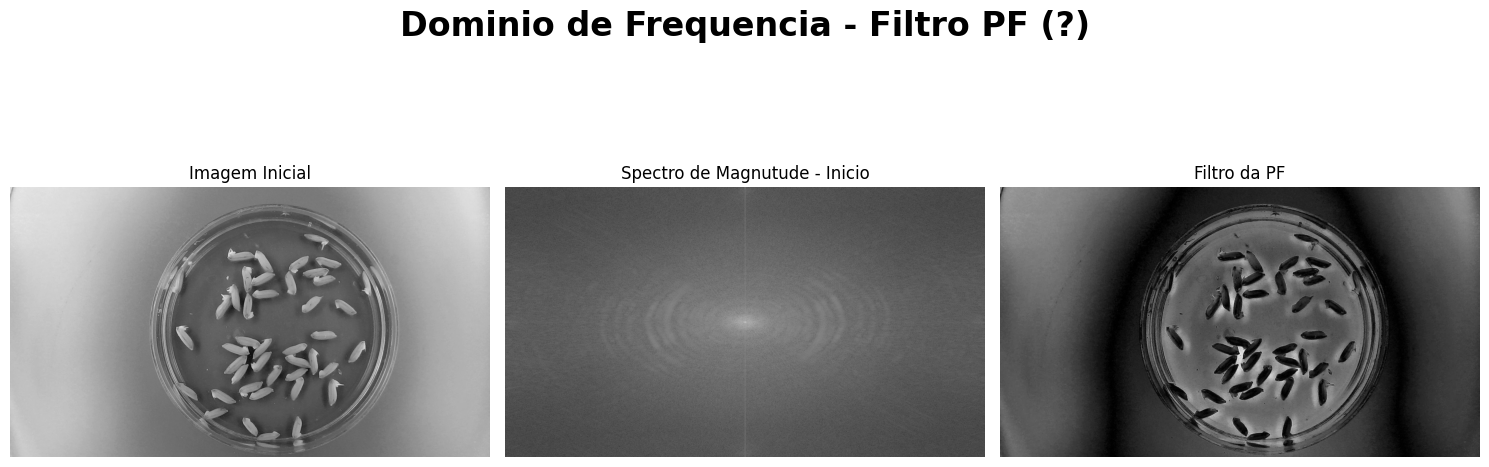

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle(f"Dominio de Frequencia - Filtro PF (?)" , fontsize=24, fontweight='bold')

axes[0].imshow(norm_img, cmap='gray')
axes[0].set_title(f'Imagem Inicial')
axes[0].axis('off')

axes[1].imshow(magnitude_spectrum, cmap = 'gray')
axes[1].set_title(f'Spectro de Magnutude - Inicio')
axes[1].axis('off')

axes[2].imshow(filtered_img, cmap = 'gray')
axes[2].set_title(f'Filtro da PF')
axes[2].axis('off')
plt.tight_layout()
plt.show()

In [93]:
maskRF = functions_m2.createRF(shape=dft_shift.shape, center=maxLoc, bandCenter=50, bandWidth=50, lpType=2, n=2)

filtered_freq = dft_shift*maskRF
f_ishift = np.fft.ifftshift(filtered_freq)  #inversa da fft
img_back = cv2.idft(f_ishift)        #inversa da dft
img_back = cv2.magnitude(img_back[:,:,0],img_back[:,:,1])  #recuperando a imagem capturando a magnitude (intesidade) 


img_back = np.array(img_back, dtype=np.float32)
filtered_img = np.abs(img_back)
filtered_img -= filtered_img.min()
filtered_img = filtered_img*255 / filtered_img.max()
filtered_img = filtered_img.astype(np.uint8)


<string>:16: RuntimeWarning: divide by zero encountered in divide


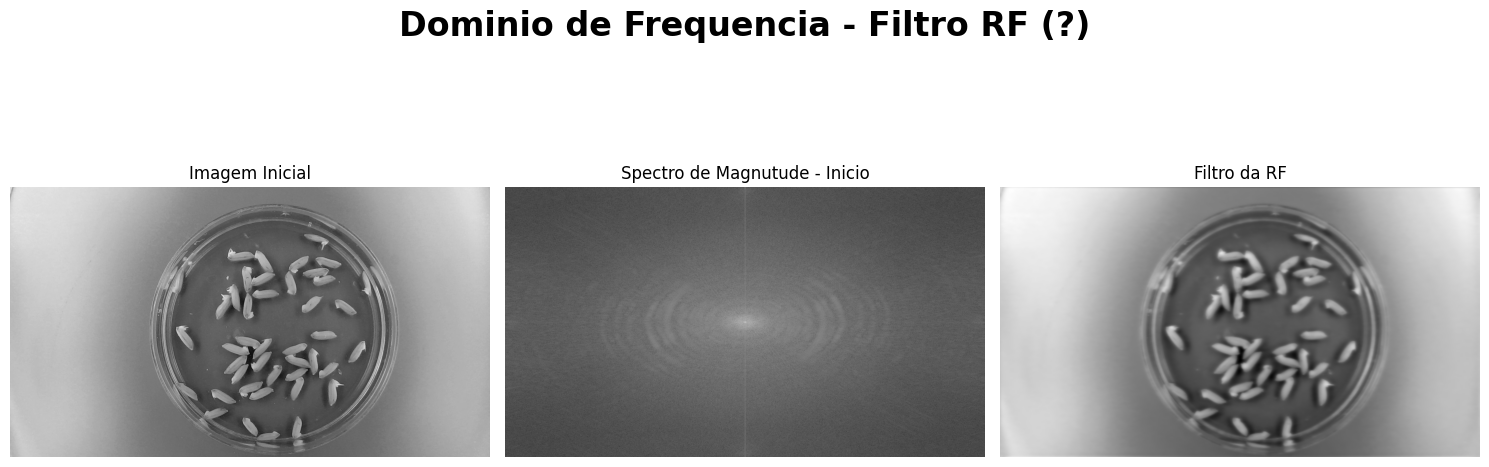

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle(f"Dominio de Frequencia - Filtro RF (?)" , fontsize=24, fontweight='bold')

axes[0].imshow(norm_img, cmap='gray')
axes[0].set_title(f'Imagem Inicial')
axes[0].axis('off')

axes[1].imshow(magnitude_spectrum, cmap = 'gray')
axes[1].set_title(f'Spectro de Magnutude - Inicio')
axes[1].axis('off')

axes[2].imshow(filtered_img, cmap = 'gray')
axes[2].set_title(f'Filtro da RF')
axes[2].axis('off')
plt.tight_layout()
plt.show()

#### Proximos passos
- Ajustar parametros do dominio de frequencia
- Aplicar a erosão, afim de remover os relfexos do espelho e separar os grãos juntos, depois, aplicar a segmentação
- Selecionar o algoritmo de Segmentação
- 